In [104]:
import matplotlib.pyplot as plt
import numpy as np

In [105]:
# Define state space dimensions
B_STATES = 5 # for B = 0, 1, 2, 3, 4
W_STATES = 5 # for W = 0, 1, 2, 3, 4
C_STATES = 3 # for C = 0, 1, 2

# Total number of regular states
NUM_REGULAR_STATES = B_STATES * W_STATES * C_STATES # 5 * 5 * 3 = 75

# Total number of states including the failure state (index 75)
NUM_TOTAL_STATES = NUM_REGULAR_STATES + 1 # 75 + 1 = 76

# Number of actions
NUM_ACTIONS = 3

# Define action indices
AC = 0 # Action Charge
AS = 1 # Action Solar
AE = 2 # Action Export


def factors_to_state(b, w, c):
    """
    Converts (b, w, c) factors to a unique state index.
    Raises ValueError if factors are outside defined ranges.
    """
    if not (0 <= b < B_STATES and 0 <= w < W_STATES and 0 <= c < C_STATES):
        raise ValueError(f"Invalid factors: b={b}, w={w}, c={c} must be within defined space dimensions.")
        
    return b * (W_STATES * C_STATES) + w * C_STATES + c

def state_to_factors(state_index):
    """
    Converts a state index to (b, w, c) factors.
    Handles the failure state (index NUM_REGULAR_STATES) by returning (-1, -1, -1).
    Raises ValueError for invalid regular state indices.
    """
    if state_index == NUM_REGULAR_STATES: # State 75 is the failure state
        return (-1, -1, -1) # Indicating a non-factorable failure state
    
    if not (0 <= state_index < NUM_REGULAR_STATES):
        raise ValueError(f"Invalid state_index: {state_index}. Must be between 0 and {NUM_TOTAL_STATES}")
        
    b = state_index // (W_STATES * C_STATES)
    remaining_index = state_index % (W_STATES * C_STATES)
    w = remaining_index // C_STATES
    c = remaining_index % C_STATES
    return (b, w, c)

def create_complex_transition_matrix():
    """
    Creates and populates the 3D transition tensor (T) with probabilistic transitions.
    T has shape (NUM_ACTIONS, NUM_TOTAL_STATES, NUM_TOTAL_STATES).
    """
    T = np.zeros((NUM_ACTIONS, NUM_TOTAL_STATES, NUM_TOTAL_STATES))
    failure_state_index = NUM_TOTAL_STATES - 1
    
    # Weather Transition Matrix P(W_next | W_current)
    # P_W[W_current, W_next]
    P_W = np.zeros((W_STATES, W_STATES))
    P_W[0, 1] = 0.3
    P_W[0, 0] = 0.7
    P_W[1, 2] = 0.4
    P_W[1, 0] = 0.3
    P_W[1, 1] = 0.3
    P_W[2, 3] = 0.4
    P_W[2, 2] = 0.3
    P_W[2, 1] = 0.3
    P_W[3, 4] = 0.4
    P_W[3, 3] = 0.3
    P_W[3, 2] = 0.3
    P_W[4, 4] = 0.7
    P_W[4, 3] = 0.3
    
    # Consumption Probability Function P(C_next | W_next)
    def get_prob_c_next(c_next_val, w_next_val):
        if w_next_val in [0, 1]: # If W_next is 1 or 2, C uniform over [1, 2, 3, 4]
            if c_next_val >= 1 and c_next_val <= 2:
                return 0.5
            else:
                return 0.0
        elif w_next_val == 2: # If W_next is 0, C uniform over [0, 1, 2]
            if c_next_val >= 0 and c_next_val <= 2:
                return 1 / 3
            else:
                return 0.0
        else:  # w_next_val in [3, 4]
            if c_next_val >= 0 and c_next_val <= 1:
                return 0.5
            else:
                return 0.0

    # Failure state transitions to itself for all actions with probability 1
    for action_idx in range(NUM_ACTIONS):
        T[action_idx, failure_state_index, failure_state_index] = 1.0

    # Populate transitions for regular states (0 to NUM_REGULAR_STATES - 1)
    for s_current in range(NUM_REGULAR_STATES):
        b_current, w_current, c_current = state_to_factors(s_current)

        # --- Handle Action 0 (Charge) ---
        action_idx = AC

        # Calculate deterministic B_next for normal charge outcome
        b_next_AC_normal = min(max(b_current - c_current, 0) + 1, B_STATES - 1)

        # Distribute the remaining probability (1 - prob_failure_AC) over possible W_next and C_next
        for w_next_val in range(W_STATES):
            for c_next_val in range(C_STATES):
                prob_w_c_transition = P_W[w_current, w_next_val] * get_prob_c_next(c_next_val, w_next_val)
                
                if prob_w_c_transition > 0:
                    s_next = factors_to_state(b_next_AC_normal, w_next_val, c_next_val)
                    T[action_idx, s_current, s_next] += prob_w_c_transition


        # --- Handle Action 1 (Solar - AS) ---
        action_idx = AS
        failure_prob_AS = 0.0
        
        # Determine charging probability based on current weather
        charge_prob_AS = 0.0
        
        if w_current == 4:
            charge_prob_AS = 0.95
        elif w_current == 3:
            charge_prob_AS = 0.8
        elif w_current == 2:
            charge_prob_AS = 0.5
        elif w_current == 1:
            charge_prob_AS = 0.2
        elif w_current == 0:
            charge_prob_AS = 0.05
            failure_prob_AS = 0.02

        # Calculate deterministic B_next for charged and uncharged outcomes
        b_next_AS_uncharged = max(b_current - c_current, 0)
        b_next_AS_charged = min(b_next_AS_uncharged + 1, B_STATES - 1)

        # Distribute probabilities over possible W_next and C_next for both outcomes
        for w_next_val in range(W_STATES):
            for c_next_val in range(C_STATES):
                prob_w_c_transition = P_W[w_current, w_next_val] * get_prob_c_next(c_next_val, w_next_val)
                
                if prob_w_c_transition > 0:
                    # Add probability for the 'charged' outcome
                    s_next_charged = factors_to_state(b_next_AS_charged, w_next_val, c_next_val)
                    T[action_idx, s_current, s_next_charged] += charge_prob_AS * prob_w_c_transition

                    # Add probability for the 'uncharged' outcome
                    s_next_uncharged = factors_to_state(b_next_AS_uncharged, w_next_val, c_next_val)
                    T[action_idx, s_current, s_next_uncharged] += (1 - charge_prob_AS - failure_prob_AS) * prob_w_c_transition

                    # Add probability for the 'failure' outcome
                    T[action_idx, s_current, failure_state_index] += failure_prob_AS * prob_w_c_transition


        # --- Handle Action 2 (Export - AE) ---
        action_idx = AE
        failure_prob_AE = 0.0
        
        # Calculate deterministic B_next based on current B and C
        b_next_AE = max(b_current - c_current - 1, 0)

        if b_next_AE == 0:
            failure_prob_AE = 0.05

        T[action_idx, s_current, failure_state_index] += failure_prob_AE

        # Distribute probabilities over possible W_next and C_next
        for w_next_val in range(W_STATES):
            for c_next_val in range(C_STATES):
                prob_w_c_transition = P_W[w_current, w_next_val] * get_prob_c_next(c_next_val, w_next_val) * (1 - failure_prob_AE)
                
                if prob_w_c_transition > 0:
                    s_next = factors_to_state(int(b_next_AE), w_next_val, c_next_val)
                    T[action_idx, s_current, s_next] += prob_w_c_transition
                    

    for a in range(T.shape[0]):
        for s in range(T.shape[1]):
            assert np.all(np.isclose(T[a, s].sum(), 1.0)), (s, a, T[a, s].sum())
            
    return T


In [106]:
# --- Main execution --- 
# Create the complex transition matrix
T_complex = create_complex_transition_matrix()

def print_transition_examples(action_idx, action_name, max_initial_states_to_show=5, max_transitions_per_initial_state=3):
    print(f"\n--- Examples for Action {action_idx} ({action_name}) ---")
    
    # Define some interesting example states (b, w, c) to showcase different scenarios
    example_states = [
        (0, 0, 0),   # Low battery, no sun, no consumption
        (4, 2, 0),   # Full battery, sunny, no consumption
        (1, 4, 0),   # Low battery, no sun, high consumption (potential for 0 battery)
        (3, 1, 2),   # Medium battery, cloudy, medium consumption
        (0, 4, 2)    # Empty battery, sunny, high consumption (challenging state)
    ]
    
    states_shown_count = 0
    
    for b_cur, w_cur, c_cur in example_states:
        if states_shown_count >= max_initial_states_to_show:
            break
            
        s_current = factors_to_state(b_cur, w_cur, c_cur)
        print(f"  From Initial State {s_current} ({b_cur},{w_cur},{c_cur}):")
        transitions_for_state = []
        
        for s_next in range(NUM_TOTAL_STATES):
            prob = T_complex[action_idx, s_current, s_next]
            
            if prob > 0:
                transitions_for_state.append((prob, s_next))

        # Sort by probability descending
        transitions_for_state.sort(key=lambda x: x[0], reverse=True)
        transitions_printed_for_this_state = 0
        
        for prob, s_next in transitions_for_state:
            if transitions_printed_for_this_state >= max_transitions_per_initial_state:
                break
            
            if s_next == NUM_TOTAL_STATES - 1: # Failure state
                print(f"    to Failure State {s_next} with P = {prob:.4f}")
            else:
                b_next, w_next, c_next = state_to_factors(s_next)
                print(f"    to State {s_next} ({b_next},{w_next},{c_next}) with P = {prob:.4f}")
                
            transitions_printed_for_this_state += 1
        
        if transitions_printed_for_this_state == 0:
            print("    No transitions with P > 0 found (this should not happen for valid MDPs unless states are terminal).")
            
        states_shown_count += 1

# Print examples for each action
print_transition_examples(AC, "Charge", max_initial_states_to_show=5, max_transitions_per_initial_state=3)
print_transition_examples(AS, "Solar", max_initial_states_to_show=5, max_transitions_per_initial_state=3)
print_transition_examples(AE, "Export", max_initial_states_to_show=5, max_transitions_per_initial_state=3)

# Demonstrate state conversion functions with examples (unchanged from before)
print("\n--- Demonstrating state conversion functions (unchanged) ---")
print(f"Factors (0, 0, 0) -> State: {factors_to_state(0, 0, 0)}")
print(f"Factors (4, 4, 2) -> State: {factors_to_state(4, 4, 2)}") # Max regular state
print(f"State 0 -> Factors: {state_to_factors(0)}")
print(f"State 74 -> Factors: {state_to_factors(74)}") # Max regular state
print(f"State 75 (Failure) -> Factors: {state_to_factors(75)}") # Failure state


--- Examples for Action 0 (Charge) ---
  From Initial State 0 (0,0,0):
    to State 16 (1,0,1) with P = 0.3500
    to State 17 (1,0,2) with P = 0.3500
    to State 19 (1,1,1) with P = 0.1500
  From Initial State 66 (4,2,0):
    to State 69 (4,3,0) with P = 0.2000
    to State 70 (4,3,1) with P = 0.2000
    to State 64 (4,1,1) with P = 0.1500
  From Initial State 27 (1,4,0):
    to State 42 (2,4,0) with P = 0.3500
    to State 43 (2,4,1) with P = 0.3500
    to State 39 (2,3,0) with P = 0.1500
  From Initial State 50 (3,1,2):
    to State 31 (2,0,1) with P = 0.1500
    to State 32 (2,0,2) with P = 0.1500
    to State 34 (2,1,1) with P = 0.1500
  From Initial State 14 (0,4,2):
    to State 27 (1,4,0) with P = 0.3500
    to State 28 (1,4,1) with P = 0.3500
    to State 24 (1,3,0) with P = 0.1500

--- Examples for Action 1 (Solar) ---
  From Initial State 0 (0,0,0):
    to State 1 (0,0,1) with P = 0.3255
    to State 2 (0,0,2) with P = 0.3255
    to State 4 (0,1,1) with P = 0.1395
  From I

In [107]:
GAMMA = 0.9 # Discount Factor

In [108]:
# ─────────────────────────────────────────────
# Cost function
# ─────────────────────────────────────────────
def create_cost_matrix():
    """
    C[s, a]: immediate cost of taking action a in state s.
    Shape: (NUM_TOTAL_STATES, NUM_ACTIONS)

    Energy balance:
      - Grid covers consumption deficit  max(c-b, 0)  at 10/unit
      - AC (Charge):  buy 1 extra unit from grid  -> +10
      - AS (Solar):   no grid purchase             -> +0
      - AE (Export):  sell 1 unit to grid          -> -5
      - Failure state (s=75): recurring cost 500
    """
    C = np.zeros((NUM_TOTAL_STATES, NUM_ACTIONS))
    failure_state = NUM_TOTAL_STATES - 1

    C[failure_state, :] = 500.0  # recurring absorbing-state penalty

    for s in range(NUM_REGULAR_STATES):
        b, w, c = state_to_factors(s)
        deficit_cost = 10.0 * max(c - b, 0)

        C[s, AC] = deficit_cost + 10.0   # grid charge: always buys 1 unit
        C[s, AS] = deficit_cost          # solar: covers only deficit
        C[s, AE] = deficit_cost - 5.0   # export: earns 5

    return C


# ─────────────────────────────────────────────
# Value Iteration
# ─────────────────────────────────────────────
def value_iteration(T, C, gamma=GAMMA, epsilon=1e-6, max_iter=10_000):
    """
    Minimisation Value Iteration.

    Bellman optimality operator:
        V_{k+1}(s) = min_a [ C(s,a) + gamma * sum_{s'} T[a,s,s'] * V_k(s') ]

    Returns:
        V   : optimal cost-to-go, shape (S,)
        pi  : greedy policy,       shape (S,)
        hist: dict with 'bellman_errors' and 'policy_changes' per iteration
    """
    n_states = C.shape[0]
    V  = np.zeros(n_states)
    pi = np.zeros(n_states, dtype=int)

    bellman_errors   = []
    policy_changes   = []

    for k in range(max_iter):
        # Q[s, a] = C[s,a] + gamma * (T[a] @ V)[s]
        # (T @ V) has shape (A, S)  ->  transpose to (S, A)
        Q     = C + gamma * (T @ V).T     # (S, A)
        V_new = np.min(Q,    axis=1)      # (S,)
        pi_new = np.argmin(Q, axis=1)     # (S,)

        be = float(np.max(np.abs(V_new - V)))
        nc = int(np.sum(pi_new != pi))
        bellman_errors.append(be)
        policy_changes.append(nc)

        V  = V_new
        pi = pi_new

        if be < epsilon:
            print(f"VI converged in {k+1} iterations  (Bellman error = {be:.2e})")
            break
    else:
        print(f"VI reached max_iter={max_iter} without converging.")

    return V, pi, {'bellman_errors': bellman_errors, 'policy_changes': policy_changes}


# ─────────────────────────────────────────────
# Policy Iteration
# ─────────────────────────────────────────────
def policy_iteration(T, C, gamma=GAMMA, max_iter=500):
    """
    Policy Iteration (exact policy evaluation via linear solve).

    Each iteration:
      1. Policy Evaluation:  solve  (I - gamma*T_pi) V = C_pi
      2. Policy Improvement: pi_new(s) = argmin_a Q(s,a)

    Returns:
        V   : optimal cost-to-go, shape (S,)
        pi  : optimal policy,     shape (S,)
        hist: dict with 'policy_changes' per iteration
    """
    n_states = C.shape[0]
    pi = np.zeros(n_states, dtype=int)   # initialise: AC everywhere
    I  = np.eye(n_states)

    policy_changes = []

    for k in range(max_iter):
        # ── Policy Evaluation ──────────────────────────────────────────
        # T_pi[s, s'] = T[pi[s], s, s']
        T_pi = T[pi, np.arange(n_states), :]   # (S, S)
        C_pi = C[np.arange(n_states), pi]       # (S,)

        # Solve: (I - gamma * T_pi) @ V = C_pi  (exact)
        V = np.linalg.solve(I - gamma * T_pi, C_pi)

        # ── Policy Improvement ─────────────────────────────────────────
        Q      = C + gamma * (T @ V).T          # (S, A)
        pi_new = np.argmin(Q, axis=1)

        nc = int(np.sum(pi_new != pi))
        policy_changes.append(nc)
        pi = pi_new

        if nc == 0:
            print(f"PI converged in {k+1} iterations.")
            break
    else:
        print(f"PI reached max_iter={max_iter} without converging.")

    return V, pi, {'policy_changes': policy_changes}

## Question 2.

=== Value Iteration ===
VI converged in 192 iterations  (Bellman error = 9.11e-07)

=== Policy Iteration ===
PI converged in 4 iterations.

Policy agreement : 76/76 states (100.0%)
Max |V_VI - V_PI|: 8.1947e-06


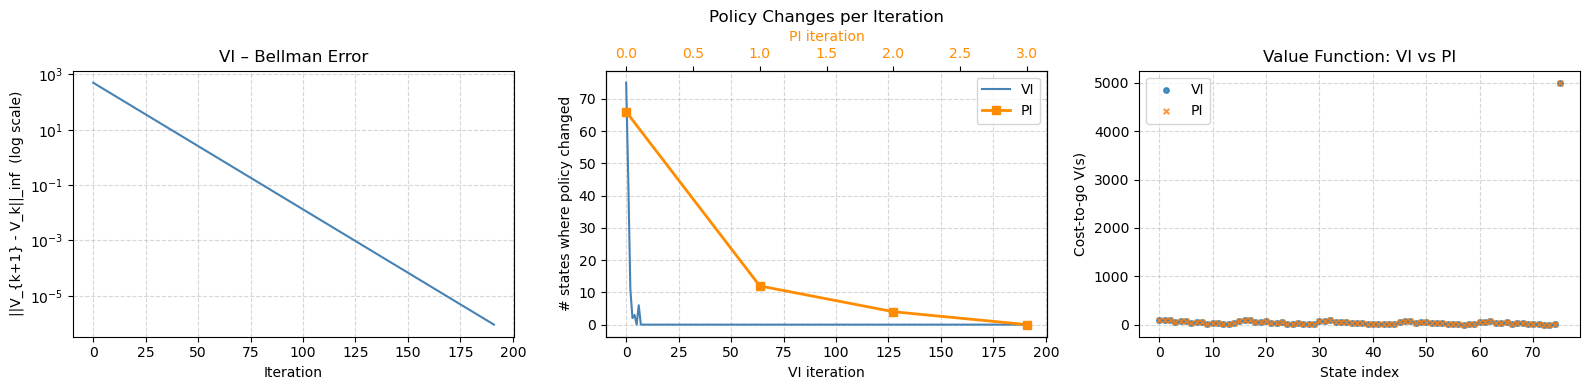


─── Sample optimal policy (VI) ───
State (b,w,c)            V_VI  Action
─────────────────────────────────────
  (0,0,0)                 88.41  AC (Charge)
  (0,4,0)                 13.49  AS (Solar)
  (1,0,2)                 98.41  AC (Charge)
  (2,2,1)                 35.93  AS (Solar)
  (3,3,0)                 12.18  AS (Solar)
  (4,4,0)                  2.91  AE (Export)
  (4,0,2)                 73.30  AC (Charge)
  Failure (75)          5000.00  AC (Charge)


In [109]:
C_matrix = create_cost_matrix()

print("=== Value Iteration ===")
V_vi, pi_vi, hist_vi = value_iteration(T_complex, C_matrix)

print("\n=== Policy Iteration ===")
V_pi, pi_pi, hist_pi = policy_iteration(T_complex, C_matrix)

policy_agree = int(np.sum(pi_vi == pi_pi))
max_V_diff   = float(np.max(np.abs(V_vi - V_pi)))
print(f"\nPolicy agreement : {policy_agree}/{NUM_TOTAL_STATES} states "
      f"({100*policy_agree/NUM_TOTAL_STATES:.1f}%)")
print(f"Max |V_VI - V_PI|: {max_V_diff:.4e}")

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Bellman error (VI)
axes[0].semilogy(hist_vi['bellman_errors'], color='steelblue')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('||V_{k+1} - V_k||_inf  (log scale)')
axes[0].set_title('VI – Bellman Error')
axes[0].grid(True, which='both', ls='--', alpha=0.5)

# 2. Policy changes per iteration
axes[1].plot(hist_vi['policy_changes'], color='steelblue', lw=1.5, label='VI')
axes[1].set_xlabel('VI iteration')
axes[1].set_ylabel('# states where policy changed')
axes[1].set_title('Policy Changes per Iteration')
axes[1].grid(True, ls='--', alpha=0.5)

ax_pi = axes[1].twiny()
ax_pi.plot(hist_pi['policy_changes'], color='darkorange', lw=2,
           marker='s', ms=6, label='PI')
ax_pi.set_xlabel('PI iteration', color='darkorange')
ax_pi.tick_params(axis='x', labelcolor='darkorange')

lines_vi, labels_vi = axes[1].get_legend_handles_labels()
lines_pi, labels_pi = ax_pi.get_legend_handles_labels()
axes[1].legend(lines_vi + lines_pi, labels_vi + labels_pi, loc='upper right')

# 3. Value function comparison
axes[2].scatter(range(NUM_TOTAL_STATES), V_vi, s=15, alpha=0.8,
                label='VI', zorder=3)
axes[2].scatter(range(NUM_TOTAL_STATES), V_pi, s=15, alpha=0.8,
                marker='x', label='PI', zorder=3)
axes[2].set_xlabel('State index')
axes[2].set_ylabel('Cost-to-go V(s)')
axes[2].set_title('Value Function: VI vs PI')
axes[2].legend()
axes[2].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

action_names = {AC: 'AC (Charge)', AS: 'AS (Solar)', AE: 'AE (Export)'}
print("\n─── Sample optimal policy (VI) ───")
header = f"{'State (b,w,c)':<18} {'V_VI':>10}  {'Action'}"
print(header)
print("─" * len(header))
sample = [(0,0,0), (0,4,0), (1,0,2), (2,2,1), (3,3,0), (4,4,0), (4,0,2)]
for b, w, c in sample:
    s = factors_to_state(b, w, c)
    print(f"  ({b},{w},{c}){'':<11} {V_vi[s]:>10.2f}  {action_names[pi_vi[s]]}")
failure_s = NUM_TOTAL_STATES - 1
print(f"  Failure (75)       {V_vi[failure_s]:>10.2f}  {action_names[pi_vi[failure_s]]}")

## Question 3.

In [110]:
def create_custom_cost_matrix(grid_cost=10.0, export_rev=-5.0, fail_pen=500.0):
    """Generates a cost matrix based on custom economic parameters."""
    C = np.zeros((NUM_TOTAL_STATES, NUM_ACTIONS))
    failure_state = NUM_TOTAL_STATES - 1
    
    C[failure_state, :] = fail_pen
    
    for s in range(NUM_REGULAR_STATES):
        b, w, c = state_to_factors(s)
        deficit = max(c - b, 0)
        deficit_cost = grid_cost * deficit
        
        C[s, AC] = deficit_cost + grid_cost
        C[s, AS] = deficit_cost
        C[s, AE] = deficit_cost + export_rev
        
    return C

def evaluate_cost_impact():
    # 3 cost scenarios
    scenarios = {
        "Baseline (Fail=500, Exp=-5)": create_custom_cost_matrix(10.0, -5.0, 500.0),
        "High Export (Fail=500, Exp=-20)": create_custom_cost_matrix(10.0, -20.0, 500.0),
        "Low Failure (Fail=20, Exp=-5)": create_custom_cost_matrix(10.0, -5.0, 20.0)
    }
    
    states_to_print = [0, 5, 32, 49, 75]
    action_names = ['AC', 'AS', 'AE']
    
    for name, C in scenarios.items():
        print(f"\n{'='*50}")
        print(f"--- {name} ---")
        
        print("Requested Cost Entries C(s, a):")
        print(f"{'State':<10} | {'AC (Charge)':<12} | {'AS (Solar)':<12} | {'AE (Export)':<12}")
        print("-" * 55)
        for s in states_to_print:
            print(f"C({s:<2}, :)   | {C[s, AC]:<12.1f} | {C[s, AS]:<12.1f} | {C[s, AE]:<12.1f}")
        
        V, pi, hist = value_iteration(T_complex, C, gamma=GAMMA)
        
        print("\nOptimal Actions for selected states:")
        for s in states_to_print[:-1]: # skip 75 as it's terminal
            b, w, c = state_to_factors(s)
            print(f"State {s} (B:{b}, W:{w}, C:{c}) -> {action_names[pi[s]]}")

evaluate_cost_impact()


--- Baseline (Fail=500, Exp=-5) ---
Requested Cost Entries C(s, a):
State      | AC (Charge)  | AS (Solar)   | AE (Export) 
-------------------------------------------------------
C(0 , :)   | 10.0         | 0.0          | -5.0        
C(5 , :)   | 30.0         | 20.0         | 15.0        
C(32, :)   | 10.0         | 0.0          | -5.0        
C(49, :)   | 10.0         | 0.0          | -5.0        
C(75, :)   | 500.0        | 500.0        | 500.0       
VI converged in 192 iterations  (Bellman error = 9.11e-07)

Optimal Actions for selected states:
State 0 (B:0, W:0, C:0) -> AC
State 5 (B:0, W:1, C:2) -> AS
State 32 (B:2, W:0, C:2) -> AC
State 49 (B:3, W:1, C:1) -> AS

--- High Export (Fail=500, Exp=-20) ---
Requested Cost Entries C(s, a):
State      | AC (Charge)  | AS (Solar)   | AE (Export) 
-------------------------------------------------------
C(0 , :)   | 10.0         | 0.0          | -20.0       
C(5 , :)   | 30.0         | 20.0         | 0.0         
C(32, :)   | 10.0      

VI converged in 192 iterations  (Bellman error = 9.11e-07)
VI converged in 192 iterations  (Bellman error = 9.11e-07)
VI converged in 161 iterations  (Bellman error = 9.55e-07)


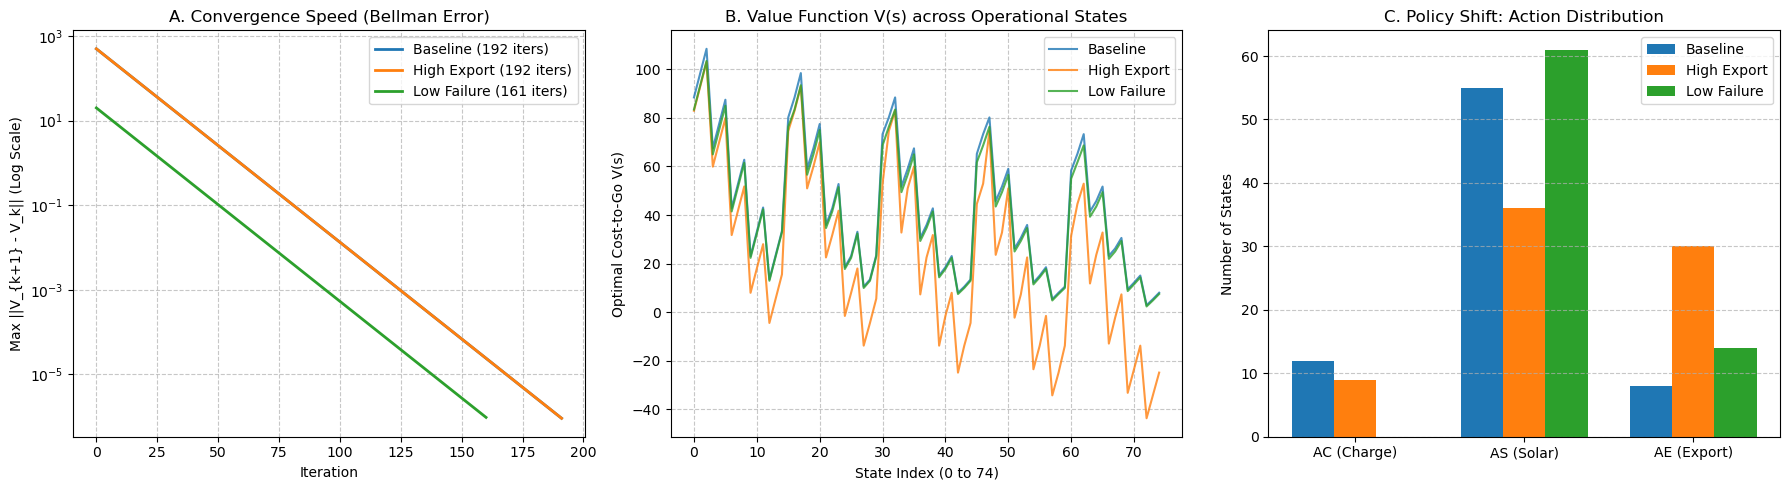

In [111]:
def plot_cost_impact():
    scenarios = {
        "Baseline": create_custom_cost_matrix(10.0, -5.0, 500.0),
        "High Export": create_custom_cost_matrix(10.0, -20.0, 500.0),
        "Low Failure": create_custom_cost_matrix(10.0, -5.0, 20.0)
    }
    
    results = {}
    for name, C in scenarios.items():
        V, pi, hist = value_iteration(T_complex, C, gamma=GAMMA)
        results[name] = {'V': V, 'pi': pi, 'hist': hist}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # --- Plot A: Convergence (Bellman Error) ---
    for (name, data), color in zip(results.items(), colors):
        axes[0].semilogy(data['hist']['bellman_errors'], label=f"{name} ({len(data['hist']['bellman_errors'])} iters)", color=color, linewidth=2)
    
    axes[0].set_title('A. Convergence Speed (Bellman Error)')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Max ||V_{k+1} - V_k|| (Log Scale)')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- Plot B: Value Function V(s) Comparison ---
    for (name, data), color in zip(results.items(), colors):
        axes[1].plot(range(75), data['V'][:75], label=name, color=color, alpha=0.8, linewidth=1.5)
        
    axes[1].set_title('B. Value Function V(s) across Operational States')
    axes[1].set_xlabel('State Index (0 to 74)')
    axes[1].set_ylabel('Optimal Cost-to-Go V(s)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # --- Plot C: Policy Shift (Action Distribution) ---
    action_counts = {name: [0, 0, 0] for name in scenarios.keys()}
    
    for name, data in results.items():
        for s in range(75):
            action_counts[name][data['pi'][s]] += 1
            
    x = np.arange(3)
    width = 0.25
    
    axes[2].bar(x - width, action_counts['Baseline'], width, label='Baseline', color=colors[0])
    axes[2].bar(x, action_counts['High Export'], width, label='High Export', color=colors[1])
    axes[2].bar(x + width, action_counts['Low Failure'], width, label='Low Failure', color=colors[2])
    
    axes[2].set_title('C. Policy Shift: Action Distribution')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(['AC (Charge)', 'AS (Solar)', 'AE (Export)'])
    axes[2].set_ylabel('Number of States')
    axes[2].legend()
    axes[2].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_cost_impact()

## Question 4.

=== Marginalized MDP — Value Iteration ===
VI converged in 192 iterations  (Bellman error = 9.11e-07)

=== Marginalized MDP — Policy Iteration ===
PI converged in 2 iterations.


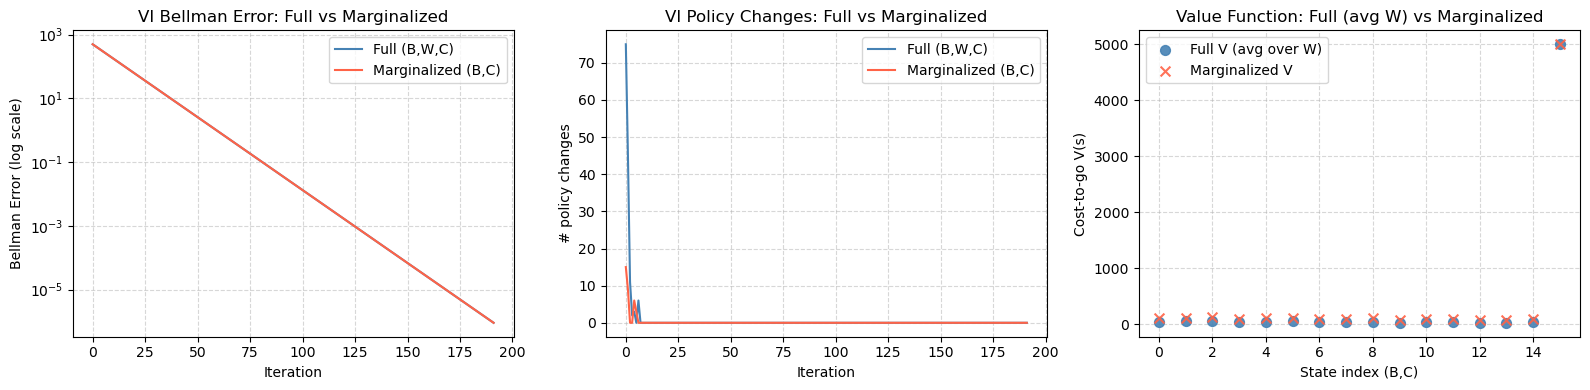


─── Policy per (b,c): Full model (one per w=0..4) vs Marginalized ───
(b,c)     w=0  w=1  w=2  w=3  w=4   Marg
────────────────────────────────────────────
(0,0)      AC    AS    AS    AS    AS     AC
(0,1)      AC    AS    AS    AS    AS     AC
(0,2)      AC    AS    AS    AS    AS     AC
(1,0)      AC    AS    AS    AS    AS     AC
(1,1)      AC    AS    AS    AS    AS     AC
(1,2)      AC    AS    AS    AS    AS     AC
(2,0)      AC    AS    AS    AS    AS     AE
(2,1)      AC    AS    AS    AS    AS     AC
(2,2)      AC    AS    AS    AS    AS     AC
(3,0)      AE    AS    AS    AS    AE     AE
(3,1)      AC    AS    AS    AS    AS     AE
(3,2)      AC    AS    AS    AS    AS     AC
(4,0)      AE    AS    AE    AE    AE     AE
(4,1)      AE    AS    AS    AS    AE     AE
(4,2)      AC    AS    AS    AS    AS     AE


In [112]:

# ─────────────────────────────────────────────────────────────────────
# Marginalized MDP: state = (B, C), weather averaged out
# ─────────────────────────────────────────────────────────────────────
NUM_BC_STATES = B_STATES * C_STATES   # 5 * 3 = 15
NUM_BC_TOTAL  = NUM_BC_STATES + 1     # 16 (failure state at index 15)
FAILURE_BC    = NUM_BC_STATES         # 15

def bc_to_state(b, c):
    return b * C_STATES + c

def state_to_bc(s):
    if s == FAILURE_BC:
        return (-1, -1)
    return (s // C_STATES, s % C_STATES)

def create_marginalized_transition_matrix(T_full):
    """
    Marginalizes T_full over the weather factor W by averaging uniformly
    over all W values for the current state.

    T_marg[a, (b,c), (b',c')] = (1/W_STATES) * sum_w  T_full[a, (b,w,c), (b',w',c')]
                                  (sum over w' is implicit via T_full rows)
    """
    T_marg = np.zeros((NUM_ACTIONS, NUM_BC_TOTAL, NUM_BC_TOTAL))
    T_marg[:, FAILURE_BC, FAILURE_BC] = 1.0  # failure is absorbing

    for s_bc in range(NUM_BC_STATES):
        b, c = state_to_bc(s_bc)
        for a in range(NUM_ACTIONS):
            for w in range(W_STATES):
                s_full = factors_to_state(b, w, c)
                for s_next_full in range(NUM_TOTAL_STATES):
                    p = T_full[a, s_full, s_next_full]
                    if p == 0:
                        continue
                    if s_next_full == NUM_TOTAL_STATES - 1:  # original failure state
                        T_marg[a, s_bc, FAILURE_BC] += p / W_STATES
                    else:
                        b_next, _, c_next = state_to_factors(s_next_full)
                        T_marg[a, s_bc, bc_to_state(b_next, c_next)] += p / W_STATES

    for a in range(NUM_ACTIONS):
        for s in range(NUM_BC_TOTAL):
            assert np.isclose(T_marg[a, s].sum(), 1.0), \
                f"T_marg[{a},{s}] sums to {T_marg[a,s].sum()}"
    return T_marg

def create_marginalized_cost_matrix():
    """Cost depends only on (B, C) — same formula, no W dimension."""
    C_marg = np.zeros((NUM_BC_TOTAL, NUM_ACTIONS))
    C_marg[FAILURE_BC, :] = 500.0
    for s_bc in range(NUM_BC_STATES):
        b, c = state_to_bc(s_bc)
        deficit_cost = 10.0 * max(c - b, 0)
        C_marg[s_bc, AC] = deficit_cost + 10.0
        C_marg[s_bc, AS] = deficit_cost
        C_marg[s_bc, AE] = deficit_cost - 5.0
    return C_marg

# ── Build and solve marginalized model ───────────────────────────────
T_marg = create_marginalized_transition_matrix(T_complex)
C_marg = create_marginalized_cost_matrix()

print("=== Marginalized MDP — Value Iteration ===")
V_vi_marg, pi_vi_marg, hist_vi_marg = value_iteration(T_marg, C_marg)

print("\n=== Marginalized MDP — Policy Iteration ===")
V_pi_marg, pi_pi_marg, hist_pi_marg = policy_iteration(T_marg, C_marg)

# ── Map full-model values to (B,C) by averaging over W ───────────────
V_full_avg = np.zeros(NUM_BC_TOTAL)
for s_bc in range(NUM_BC_STATES):
    b, c = state_to_bc(s_bc)
    V_full_avg[s_bc] = np.mean([V_vi[factors_to_state(b, w, c)] for w in range(W_STATES)])
V_full_avg[FAILURE_BC] = V_vi[NUM_TOTAL_STATES - 1]

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Bellman error comparison
axes[0].semilogy(hist_vi['bellman_errors'],      color='steelblue', label='Full (B,W,C)')
axes[0].semilogy(hist_vi_marg['bellman_errors'], color='tomato',    label='Marginalized (B,C)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Bellman Error (log scale)')
axes[0].set_title('VI Bellman Error: Full vs Marginalized')
axes[0].legend()
axes[0].grid(True, which='both', ls='--', alpha=0.5)

# 2. Policy changes comparison
axes[1].plot(hist_vi['policy_changes'],      color='steelblue', lw=1.5, label='Full (B,W,C)')
axes[1].plot(hist_vi_marg['policy_changes'], color='tomato',    lw=1.5, label='Marginalized (B,C)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('# policy changes')
axes[1].set_title('VI Policy Changes: Full vs Marginalized')
axes[1].legend()
axes[1].grid(True, ls='--', alpha=0.5)

# 3. Value function: full (avg over W) vs marginalized
axes[2].scatter(range(NUM_BC_TOTAL), V_full_avg,  s=50, alpha=0.9,
                label='Full V (avg over W)', color='steelblue', zorder=3)
axes[2].scatter(range(NUM_BC_TOTAL), V_vi_marg,   s=50, alpha=0.9,
                marker='x', label='Marginalized V', color='tomato', zorder=4)
axes[2].set_xlabel('State index (B,C)')
axes[2].set_ylabel('Cost-to-go V(s)')
axes[2].set_title('Value Function: Full (avg W) vs Marginalized')
axes[2].legend()
axes[2].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ── Policy comparison per (B, C) ──────────────────────────────────────
an = {AC: 'AC', AS: 'AS', AE: 'AE'}
print("\n─── Policy per (b,c): Full model (one per w=0..4) vs Marginalized ───")
print(f"{'(b,c)':<8} {'w=0':>4} {'w=1':>4} {'w=2':>4} {'w=3':>4} {'w=4':>4}   {'Marg':>4}")
print("─" * 44)
for s_bc in range(NUM_BC_STATES):
    b, c = state_to_bc(s_bc)
    full_acts = [an[pi_vi[factors_to_state(b, w, c)]] for w in range(W_STATES)]
    marg_act  = an[pi_vi_marg[s_bc]]
    print(f"({b},{c})    " + "  ".join(f"{a:>4}" for a in full_acts) + f"   {marg_act:>4}")
